# Pre-entrega 6 — Demo del flujo de delegación

Este notebook ejecuta el orquestador con el pedido de demostración y muestra, paso a paso:

1. el grafo;
2. la delegación en vivo (Supervisor → especialistas → Supervisor);
3. las decisiones del Supervisor ronda por ronda;
4. la proveniencia: qué aportó cada agente y con qué evidencia;
5. la respuesta final.

**Requisito:** un `.env` con `GOOGLE_API_KEY` (ver `.env.example`). El kernel tiene que estar parado en la raíz del repositorio.

In [1]:
from IPython.display import Image, Markdown, display

from comun.config import Configuracion
from comun.modelo_simulado import ModeloSimulado
from graph import construir_grafo
from main import PEDIDO_DEMO, ejecutar

config = Configuracion.desde_entorno()
print(f"Proveedor: {config.proveedor} | Modelo: {config.modelo}")
print(f"Máximo de rondas del Supervisor: {config.max_rondas_supervisor}")

Proveedor: gemini | Modelo: gemini-3.6-flash
Máximo de rondas del Supervisor: 6


## 1. El grafo

Las flechas punteadas son la arista condicional del Supervisor; las llenas, las aristas fijas de vuelta.
El diagrama depende solo de la estructura, así que se dibuja con el modelo simulado (no gasta API).

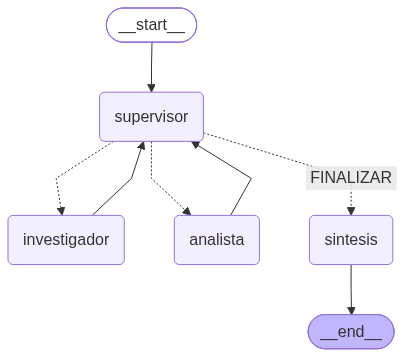

In [2]:
grafo_para_dibujar = construir_grafo(config, modelo=ModeloSimulado())
try:
    display(Image(grafo_para_dibujar.get_graph().draw_mermaid_png()))
except Exception:
    # draw_mermaid_png necesita internet (mermaid.ink); si falla, se muestra el texto Mermaid
    print(grafo_para_dibujar.get_graph().draw_mermaid())

## 2. Ejecución en vivo

Cada línea `[supervisor]` es una decisión de ruteo; `[investigador]` y `[analista]` muestran la instrucción que recibe cada especialista.
El pedido incluye una trampa: la base tiene recetas vegetarianas que **no son cenas** (budín, flan).

In [3]:
print(PEDIDO_DEMO, "\n")
final = await ejecutar(PEDIDO_DEMO)

Armame un menu de 3 cenas vegetarianas para 6 personas. Necesito la lista de compras consolidada y saber cuantas calorias come cada persona en total. 



c:\Users\cvari\AppData\Local\Programs\Python\Python312\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
Direct use of automatic function calling (AFC) in AsyncModels.generate_content is not recommended. Instead, we recommend to use AFC in AsyncChat.send_message. Similarly, direct use of AFC in AsyncModels.generate_content_stream is not recommended. Instead, we recommend to use AFC in AsyncChat.send_message_stream.


Modelo: gemini / gemini-3.6-flash
Pedido: Armame un menu de 3 cenas vegetarianas para 6 personas. Necesito la lista de compras consolidada y saber cuantas calorias come cada persona en total.

  [supervisor] ronda 1: -> investigador | Aun no hay una seleccion de recetas entregada por el investigador para cumplir con el pedido de cenas vegetarianas.
<- termino: supervisor

  [investigador] Buscar exactamente 3 recetas de cenas vegetarianas para 6 personas y entregar la seleccion de IDs correspondiente.


c:\Users\cvari\AppData\Local\Programs\Python\Python312\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\cvari\AppData\Local\Programs\Python\Python312\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\cvari\AppData\Local\Programs\Python\Python312\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


<- termino: investigador



...

<- termino: analista



c:\Users\cvari\AppData\Local\Programs\Python\Python312\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


  [supervisor] ronda 3: -> FINALIZAR | La seleccion de 3 cenas vegetarianas es correcta y el analista calculo las calorias por persona y la lista de compras requeridas para 6 personas sin fallas.
<- termino: supervisor

  [sintesis] redactando respuesta final...


c:\Users\cvari\AppData\Local\Programs\Python\Python312\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


<- termino: sintesis

¡Buenas! Acá tenés la propuesta de menú para las 3 cenas vegetarianas de 6 personas, con la información nutricional y la lista de compras necesaria.

### 1. Recetas elegidas
* **Ñoquis de papa**
* **Tortilla de papas**
* **Pizza casera de muzzarella**

---

### 2. Calorías y números
Detalle para 6 comensales:

* **Ñoquis de papa:** 450 calorías por porción (2700 calorías para el grupo)
* **Tortilla de papas:** 330 calorías por porción (1980 calorías para el grupo)
* **Pizza casera de muzzarella:** 290 calorías por porción (1740 calorías para el grupo)

* **Calorías totales del menú:** 6420 calorías
* **Calorías totales por comensal:** 1070 calorías

---

### 3. Lista de compras consolidada

**Factores de escala por receta:**
* Ñoquis de papa: 1.5
* Tortilla de papas: 1.5
* Pizza casera de muzzarella: 0.75

**Ingredientes (y en qué recetas se usan):**
* **aceite de oliva:** Tortilla de papas
* **aceituna:** Pizza casera de muzzarella
* **cebolla:** Tortilla de papa

## 3. Decisiones del Supervisor

Cada ronda: a quién delegó, por qué (evaluación según la rúbrica) y con qué instrucción.
`forzada=True` indicaría un cierre por límite de rondas, decidido por el código y no por el LLM.

In [4]:
for d in final["decisiones"]:
    print(f"Ronda {d.ronda} -> {d.siguiente}{'  (FORZADA)' if d.forzada else ''}")
    print(f"   Evaluación : {d.evaluacion}")
    if d.instruccion:
        print(f"   Instrucción: {d.instruccion}")
    print()

Ronda 1 -> investigador
   Evaluación : Aun no hay una seleccion de recetas entregada por el investigador para cumplir con el pedido de cenas vegetarianas.
   Instrucción: Buscar exactamente 3 recetas de cenas vegetarianas para 6 personas y entregar la seleccion de IDs correspondiente.

Ronda 2 -> analista
   Evaluación : La seleccion de 3 cenas vegetarianas del investigador es correcta, pero falta que el analista realice el procesamiento.
   Instrucción: Procesa las recetas seleccionadas ['r008', 'r009', 'r018'] (Ñoquis de papa, Tortilla de papas y Pizza casera de muzzarella) para 6 personas. Genera la lista de compras consolidada y calcula el total de calorias por persona.

Ronda 3 -> FINALIZAR
   Evaluación : La seleccion de 3 cenas vegetarianas es correcta y el analista calculo las calorias por persona y la lista de compras requeridas para 6 personas sin fallas.



## 4. Proveniencia: qué aportó cada agente

`aportes` es acumulativo: si el Supervisor pidió un refinamiento, se ven las dos selecciones del investigador.
La evidencia son las llamadas reales a herramientas; ahí sale cada dato de la respuesta final.

In [5]:
for a in final["aportes"]:
    print(f"[ronda {a.ronda}] {a.agente.upper()}  ids={a.receta_ids}")
    print(f"   Instrucción recibida: {a.instruccion}")
    for ev in a.evidencia:
        estado = f"ERROR: {ev.error}" if ev.error else "ok"
        print(f"   - {ev.herramienta}({ev.argumentos}) -> {estado}")
    print()

[ronda 1] INVESTIGADOR  ids=['r008', 'r009', 'r018']
   Instrucción recibida: Buscar exactamente 3 recetas de cenas vegetarianas para 6 personas y entregar la seleccion de IDs correspondiente.
   - buscar_recetas_por_etiqueta({'etiqueta': 'vegetariana'}) -> ok
   - entregar_seleccion({'justificacion': 'Se seleccionaron 3 recetas vegetarianas adecuadas para cena (ñoquis de papa, tortilla de papas y pizza casera de muzzarella), descartando opciones dulces y postres.', 'receta_ids': ['r008', 'r009', 'r018']}) -> ok

[ronda 2] ANALISTA  ids=['r008', 'r009', 'r018']
   Instrucción recibida: Procesa las recetas seleccionadas ['r008', 'r009', 'r018'] (Ñoquis de papa, Tortilla de papas y Pizza casera de muzzarella) para 6 personas. Genera la lista de compras consolidada y calcula el total de calorias por persona.
   - consolidar_lista_compras({'receta_ids': ['r008', 'r009', 'r018'], 'comensales': 6}) -> ok
   - calcular_nutricion_menu({'receta_ids': ['r008', 'r009', 'r018'], 'comensales': 6}) 

## 5. Validación final y respuesta

In [6]:
print(f"Tarea completa: {final['task_completed']}")
print(f"Motivo de cierre: {final['motivo_cierre']}")
display(Markdown(final["messages"][-1].content))

Tarea completa: True
Motivo de cierre: Rubrica cumplida y chequeos automaticos OK.


¡Buenas! Acá tenés la propuesta de menú para las 3 cenas vegetarianas de 6 personas, con la información nutricional y la lista de compras necesaria.

### 1. Recetas elegidas
* **Ñoquis de papa**
* **Tortilla de papas**
* **Pizza casera de muzzarella**

---

### 2. Calorías y números
Detalle para 6 comensales:

* **Ñoquis de papa:** 450 calorías por porción (2700 calorías para el grupo)
* **Tortilla de papas:** 330 calorías por porción (1980 calorías para el grupo)
* **Pizza casera de muzzarella:** 290 calorías por porción (1740 calorías para el grupo)

* **Calorías totales del menú:** 6420 calorías
* **Calorías totales por comensal:** 1070 calorías

---

### 3. Lista de compras consolidada

**Factores de escala por receta:**
* Ñoquis de papa: 1.5
* Tortilla de papas: 1.5
* Pizza casera de muzzarella: 0.75

**Ingredientes (y en qué recetas se usan):**
* **aceite de oliva:** Tortilla de papas
* **aceituna:** Pizza casera de muzzarella
* **cebolla:** Tortilla de papas
* **harina:** Ñoquis de papa, Pizza casera de muzzarella
* **huevo:** Ñoquis de papa, Tortilla de papas
* **levadura:** Pizza casera de muzzarella
* **oregano:** Pizza casera de muzzarella
* **papa:** Ñoquis de papa, Tortilla de papas
* **queso mozzarella:** Pizza casera de muzzarella
* **sal:** Ñoquis de papa, Tortilla de papas
* **salsa de tomate:** Ñoquis de papa, Pizza casera de muzzarella